<a href="https://colab.research.google.com/github/muralip0501/zerocrossingread/blob/main/speechemotion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import wave
import os


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

import keras
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import*
from tensorflow.keras.optimizers import RMSprop as rmsprop


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [8]:
def extract_mfcc(wav_file_name):
    y, sr= librosa.load(wav_file_name)
    mfccs= np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    return mfccs

In [9]:
import os
import librosa
import wave
import numpy as np # Added import statement

tess_speech_labels= []
tess_speech_data= []
for dirname, _, filenames in os.walk('/content/drive/MyDrive/Colab Notebooks/TESS Toronto emotional speech set data'):
    for filename in filenames: # The code below this line should be indented by 4 spaces
        tess_speech_labels.append(dirname.split('/')[-1]) # Added indentation
        wav_file_name = os.path.join(dirname, filename) # Added indentation
        tess_speech_data.append(extract_mfcc(wav_file_name)) # Added indentation
tess_speech_data


[array([-4.00862091e+02,  8.65394440e+01,  1.47986555e+01,  2.32173653e+01,
        -1.43430483e+00,  4.96457911e+00, -2.67935109e+00, -1.33711672e+01,
         5.32948780e+00, -9.18353271e+00, -7.85090923e+00,  3.16123080e+00,
        -1.19284048e+01,  9.14245701e+00, -8.21767521e+00, -3.37327647e+00,
        -4.03737426e-01, -1.34877598e+00, -7.57676506e+00, -5.51362324e+00,
        -5.93199587e+00, -7.08784103e+00, -5.98315763e+00, -7.24779218e-02,
        -3.59243703e+00,  6.40199757e+00,  3.05341792e+00,  1.93881226e+00,
        -6.13402247e-01,  1.13184094e+00, -3.00781578e-01,  1.10141811e+01,
         7.29630756e+00,  8.17084980e+00,  1.38118303e+00,  1.68573606e+00,
         2.56823039e+00,  6.84979963e+00,  7.55725479e+00,  8.58666420e+00],
       dtype=float32),
 array([-4.8778375e+02,  6.6914284e+01,  3.3566654e+01,  3.0141733e+01,
         6.2607560e+00,  1.1146859e+01, -5.3519297e-01, -6.8239608e+00,
         2.2289679e+00, -1.9983920e+00, -1.5008048e+00,  2.5971091e+00,


In [13]:
tess_speech_data_array = np.array(tess_speech_data)
tess_speech_labels_array = np.array(tess_speech_labels)
label_encoder = LabelEncoder()
tess_speech_labels_encoded = label_encoder.fit_transform(tess_speech_labels_array)
labels_categorical = to_categorical(tess_speech_labels_encoded)
tess_speech_data_array.shape

(2800, 40)

In [14]:
x_train, x_test, y_train, y_test = train_test_split(np.array(tess_speech_data_array), labels_categorical, test_size=0.5, random_state=9)

In [15]:
number_of_samples= tess_speech_data_array.shape[0]
training_samples=int(number_of_samples*0.8)
validation_samples=int(number_of_samples*0.1)
test_samples=int(number_of_samples*0.1)

In [21]:
def create_model_LSTM():
  model=Sequential()
  model.add(LSTM(128,return_sequences=False,input_shape=(40,1)))
  model.add(Dense(64))
  model.add(Dropout(0.5))
  model.add(Activation('relu'))
  model.add(Dense(32))
  model.add(Dropout(0.5))
  model.add(Activation('relu'))
  model.add(Dense(14))
  model.add(Activation('softmax'))

  model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')
  return model

In [18]:
w = np.expand_dims(tess_speech_data_array[:training_samples], -1)
w.shape

(2240, 40, 1)

In [22]:
model_A=create_model_LSTM()
history=model_A.fit(np.expand_dims(tess_speech_data_array[:training_samples],-1),labels_categorical[:training_samples], validation_data=(np.expand_dims(tess_speech_data_array[training_samples:training_samples+validation_samples],-1),labels_categorical[training_samples:training_samples+validation_samples]), epochs=50, batch_size=32)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.1315 - loss: 2.5229 - val_accuracy: 0.0000e+00 - val_loss: 3.5846
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.3436 - loss: 1.8492 - val_accuracy: 0.0000e+00 - val_loss: 3.4433
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.5252 - loss: 1.3070 - val_accuracy: 0.0000e+00 - val_loss: 4.0132
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.6359 - loss: 0.9686 - val_accuracy: 0.1893 - val_loss: 4.3927
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.7180 - loss: 0.7928 - val_accuracy: 0.2286 - val_loss: 4.9091
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.7506 - loss: 0.6680 - val_accuracy: 0.0571 - val_loss: 7.0738
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8325 - loss: 0.5091 - val_accuracy: 0.3607 - val_loss: 4.9786
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.8689 - loss: 0.4113 - val_accuracy: 0.4000 - 

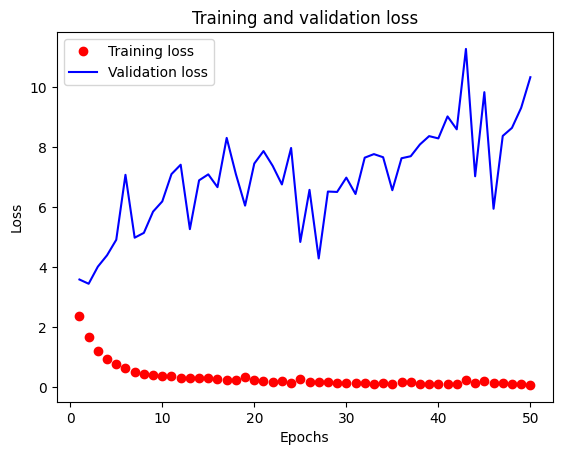

In [23]:
loss=history.history['loss']
val_loss=history.history['val_loss']
epochs=range(1,len(loss)+1)
plt.plot(epochs,loss,'ro',label='Training loss')
plt.plot(epochs,val_loss,'b',label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

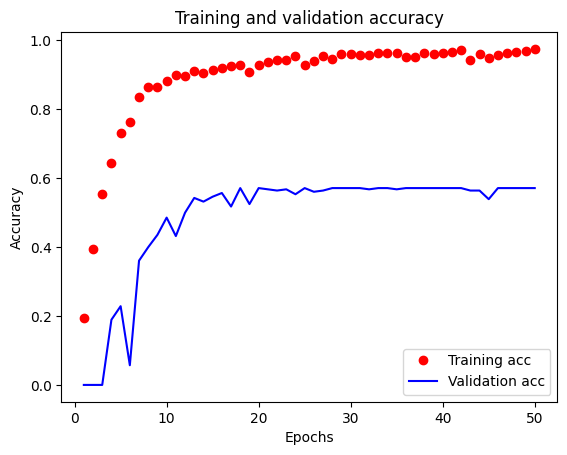

In [24]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
plt.plot(epochs,acc,'ro',label='Training acc')
plt.plot(epochs,val_acc,'b',label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [26]:
model_A.evaluate(np.expand_dims(tess_speech_data_array[training_samples+validation_samples:],-1),labels_categorical[training_samples+validation_samples:])

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0000e+00 - loss: 24.4969


[26.912410736083984, 0.0]

In [31]:
emotions={
    0:'Fear',
    1:'Pleasant',
    2:'Sad',
    3:'angry',
    4:'disgust',
    5:'happy',
    6:'neutral',
}

def predict_emotion(wav_filepath):
    test_point=extract_mfcc(wav_filepath)
    test_point=np.reshape(test_point, newshape=(1,40,1))
    predictions=model_A.predict(test_point)
    predicted_emotion=emotions[np.argmax(predictions)] # Access the dictionary using the integer index directly
    return predicted_emotion

In [33]:
predict_emotion('/content/drive/MyDrive/Colab Notebooks/TESS Toronto emotional speech set data/YAF_happy/YAF_bean_happy.wav')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


KeyError: np.int64(10)